Reading the Table of Files
Stations 230601: 142
Stations 230602: 140
Stations 230603: 140
Stations 230604: 139
Stations 230605: 139
Stations 230606: 139
Stations 230607: 139
Stations 230608: 140
Stations 230609: 141
Stations 230610: 140
Stations 230611: 140
Stations 230612: 140
Stations 230613: 138
Stations 230614: 140
Stations 230615: 138
Stations 230616: 139
Stations 230617: 140
Stations 230618: 138
Stations 230619: 139
Stations 230620: 140
Stations 230621: 139
Stations 230622: 142
Stations 230623: 141
Stations 230624: 140
Stations 230625: 140
Stations 230626: 140
Stations 230627: 141
Stations 230628: 141
Stations 230629: 140
Stations 230630: 140
Stations 230701: 140
Stations 230702: 140
Stations 230703: 140
Stations 230704: 141
Stations 230705: 138
Stations 230706: 120
Stations 230707: 142
Stations 230708: 141
Stations 230709: 141
Stations 230710: 142
Stations 230711: 144
Stations 230712: 143
Stations 230713: 139
Stations 230714: 139
Stations 230715: 138
Stations 230716: 138
Station

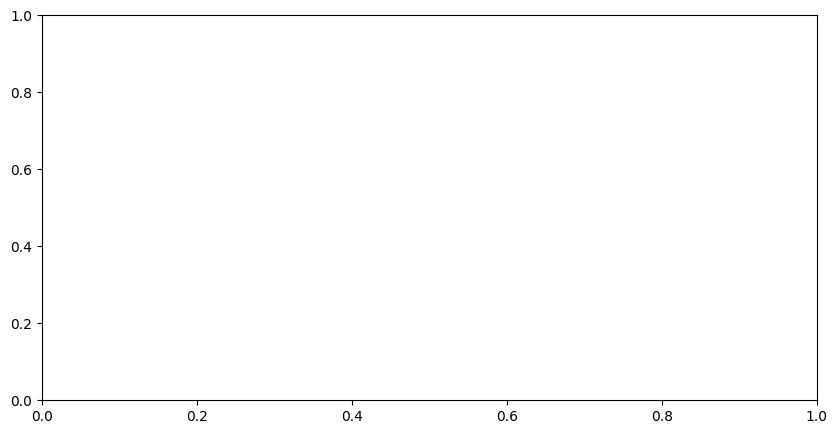

In [3]:
import os
from pathlib import Path
# Set the project folder
PRJ_PATH = Path("/Users/admin/Desktop/Monica/PhD")
INC_PATH = os.path.join(PRJ_PATH, "inc")
IMG_PATH = os.path.join(PRJ_PATH, "img")
DATA_PATH = os.path.join(PRJ_PATH, "data")
import sys
# Add to path
if INC_PATH not in sys.path: sys.path.append(INC_PATH)
import argparse
import pandas as pd
from obspy import UTCDateTime
from copy import deepcopy as dcpy

from constants import *
import analyzer as ana
import initializer as ini

args = {
  'channel': None,
  'file': [Path('/Users/admin/Desktop/Monica/PhD/data/manual')],
  'groups': ['DATE', 'NETWORK', 'station'],
  'key': None,
  'models': ['PhaseNet', 'EQTransformer'],
  'network': None,
  'station': None,
  'train': False,
  'weights': ["OGS"],
  'batch': 4096,
  'config': None,
  'directory': Path('/Users/admin/Desktop/Monica/PhD/data/waveforms'),
  'option': '*',
  'pwave': 0.5,
  'swave': 0.5,
  'client': ['http://158.110.30.217:8080'],
  'denoiser': False,
  'download': False,
  'interactive': False,
  'force': False,
  'pyrocko': False,
  'pyocto': False,
  'timing': False,
  'dates': [UTCDateTime(2023, 6, 1, 0, 0), UTCDateTime(2023, 12, 31, 0, 0)],
  'julian': None,
  'rectdomain': None,
  'circdomain': [46.3583, 12.808, 0.0, 0.3],
  'silent': False,
  'verbose': True
}
args = argparse.Namespace(**args)
DATA_PATH = args.directory.parent
STATIONS = ana._Stations(args)
print(STATIONS)
TRUE_S, TRUE_D = ana.event_parser(args.file[0], args, STATIONS)

In [ ]:
print(CLSSFD_STR)
PRED = ana._Analysis(args, CLSSFD_STR)
PRED_TP = ana.stat_test(dcpy(TRUE_D), dcpy(PRED), args, CLSSFD_STR)
print(PRED_TP)
#ana.time_displacement(PRED_TP, args, CLSSFD_STR)

In [ ]:
print(SOURCE_STR)
PRED_S = ini.data_loader(Path(
  DATA_PATH, ("D_" if args.denoiser else EMPTY_STR) + SOURCE_STR + 
  CSV_EXT))
PRED_S[TIMESTAMP_STR] = PRED_S[TIMESTAMP_STR].apply(lambda x:
                                                    UTCDateTime(x))
ana.time_displacement(ana.stat_test(TRUE_S, PRED_S, args, SOURCE_STR), args,
                  SOURCE_STR)

In [ ]:
method = CLSSFD_STR
STAT = list()
for model in args.models:
  for weight in args.weights:
    for stat in [TP_STR, FP_STR, FN_STR]:
      if method in [CLSSFD_STR, SOURCE_STR]:
        for phase in [PWAVE, SWAVE]:
          STAT.append([model, weight, stat + phase, *([0.]*len(THRESHOLDS))])
      else:
        STAT.append([model, weight, stat, *([0.] * len(THRESHOLDS))])
STAT = pd.DataFrame(STAT, columns=HEADER_STAT)
STAT_FILEPATH = Path(DATA_PATH, ("D_" if args.denoiser else EMPTY_STR) +
                    UNDERSCORE_STR.join([method, STAT_STR]) + CSV_EXT)
stat = pd.read_csv(STAT_FILEPATH)
head = [MODEL_STR, WEIGHT_STR, STAT_STR]
for _, row in stat.iterrows():
  r = STAT.loc[(STAT[head] == row[head]).all(axis=1)]
  # If the row is not in the dataframe, add it
  if r.empty: STAT.loc[len(STAT)] = row.tolist()
  # If the row is in the dataframe, update it
  else:
    STAT.loc[(STAT[head] == row[head]).all(axis=1)] = row.tolist()
print(STAT)

In [ ]:
WAVEFORMS = ini.waveform_table(args)
import seisbench.data as sbd
import seisbench.util as sbu
import obspy
DATASET_PATH = Path("/Users/admin/.seisbench/datasets/OGS")
print(f"Creating {args.weights} dataset path:", DATASET_PATH)
DATASET_PATH.mkdir(parents=True, exist_ok=True)
METADATA_PATH = Path(DATASET_PATH, METADATA_STR + CSV_EXT)
WAVEFORMS_PATH = Path(DATASET_PATH, WAVEFORMS_STR + HDF5_EXT)
with sbd.WaveformDataWriter(METADATA_PATH, WAVEFORMS_PATH) as WFW:
  WFW.data_format = {
    "dimension_order": "CW",
    "component_order": "ZNE",
    "measurement": "velocity",
    "unit": "counts",
    "instrument_response": "not restituted",
  }
  for _, SRC in TRUE_S.iterrows():
    idx = SRC[ID_STR]
    date = SRC[TIMESTAMP_STR].strftime(DATE_FMT)
    latitude = SRC[LATITUDE_STR]
    longitude = SRC[LONGITUDE_STR]
    depth = SRC[LOCAL_DEPTH_STR]
    magnitude = SRC[MAGNITUDE_STR]
    event_params = {
      "source_id": idx,
      "source_origin_time": SRC[TIMESTAMP_STR],
      "source_latitude_deg": latitude,
      "source_longitude_deg": longitude,
      "source_depth_km": depth,
      "source_magnitude": magnitude,
      "split": "train"
    }
    for station, DTC in TRUE_D[TRUE_D[ID_STR] == idx].groupby(STATION_STR):
      traces = list(WAVEFORMS[(WAVEFORMS[STATION_STR] == station) &
                              (WAVEFORMS[DATE_STR] == date)].index)
      if len(traces) == 0: continue
      start = DTC[TIMESTAMP_STR].min() - PICK_OFFSET_TRAIN
      end = DTC[TIMESTAMP_STR].max() + PICK_OFFSET_TRAIN
      stream = obspy.Stream()
      for trace in traces:
        if not Path(trace).exists(): continue
        # TODO: Warning msg
        stream += obspy.read(trace, starttime=start, endtime=end,
                             nearest_sample=True)
        stream.resample(SAMPLING_RATE)
      # TODO: Warning msg
      if len(stream) == 0: continue
      actual_t_start, data, _ = sbu.stream_to_array(
        stream, component_order=WFW.data_format["component_order"])
      trace_params = {
        "station_network_code": stream[-1].stats.network,
        "station_code": stream[-1].stats.station,
        "trace_channel": stream[-1].stats.channel,
        "station_location_code": stream[-1].stats.location,
        "trace_sampling_rate_hz": SAMPLING_RATE,
        "trace_start_time": str(actual_t_start)
      }
      for phase, pick in DTC.groupby(PHASE_STR):
        sample = int((pick[TIMESTAMP_STR].iloc[0] - actual_t_start) * SAMPLING_RATE)
        trace_params[f"trace_{phase}_status"] = "manual"
        trace_params[f"trace_{phase}_arrival_sample"] = int(sample)

      WFW.add_trace({**event_params, **trace_params}, data)


Constructing the Table of Files
Creating ['OGS'] dataset path: /Users/admin/.seisbench/datasets/OGS


Traces converted: 32it [00:00, 60.91it/s]
